In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import parameters as p
import auxiliary_funcs as af 
import collisions_vec as col
import monte_carlo_vec as mc

import pickle

# TESTING TIME - DXX = 0

In [40]:
NUMPARTICLES = 1e3 # 1e4
ISOTROPIC_SOURCE = np.vstack([np.ones(int(NUMPARTICLES)), np.linspace(-1, 1, int(NUMPARTICLES))]).T
DT = 1e-5
NUMSTEPS = int(1e6)
R=5
PHI=0.10

In [ ]:
# alejandro - 48s 1e3 particles 
filename = f'test_vec/alej_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
loss_vel, loss_step, _, _ = mc.run_mc_nopar(ISOTROPIC_SOURCE, numsteps=NUMSTEPS, D_func=col.D_nopar, A_func=col.A_alej, dt=DT, R=R, Phi=PHI)

with open(filename, "wb") as f:
    pickle.dump((loss_vel, loss_step), f)

 10%|█         | 102839/1000000 [00:48<07:00, 2133.92it/s]


In [ ]:
# no parallel - 1 min 1e3 particles
filename = f'test_vec/nopar_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
loss_vel, loss_step, _, _ = mc.run_mc_nopar(ISOTROPIC_SOURCE, numsteps=NUMSTEPS, D_func=col.D_nopar, A_func=col.A_nopar, dt=DT, R=R, Phi=PHI)

with open(filename, "wb") as f:
    pickle.dump((loss_vel, loss_step), f)

 10%|█         | 102839/1000000 [01:03<09:14, 1618.09it/s]


(629, 2)
(427, 2)


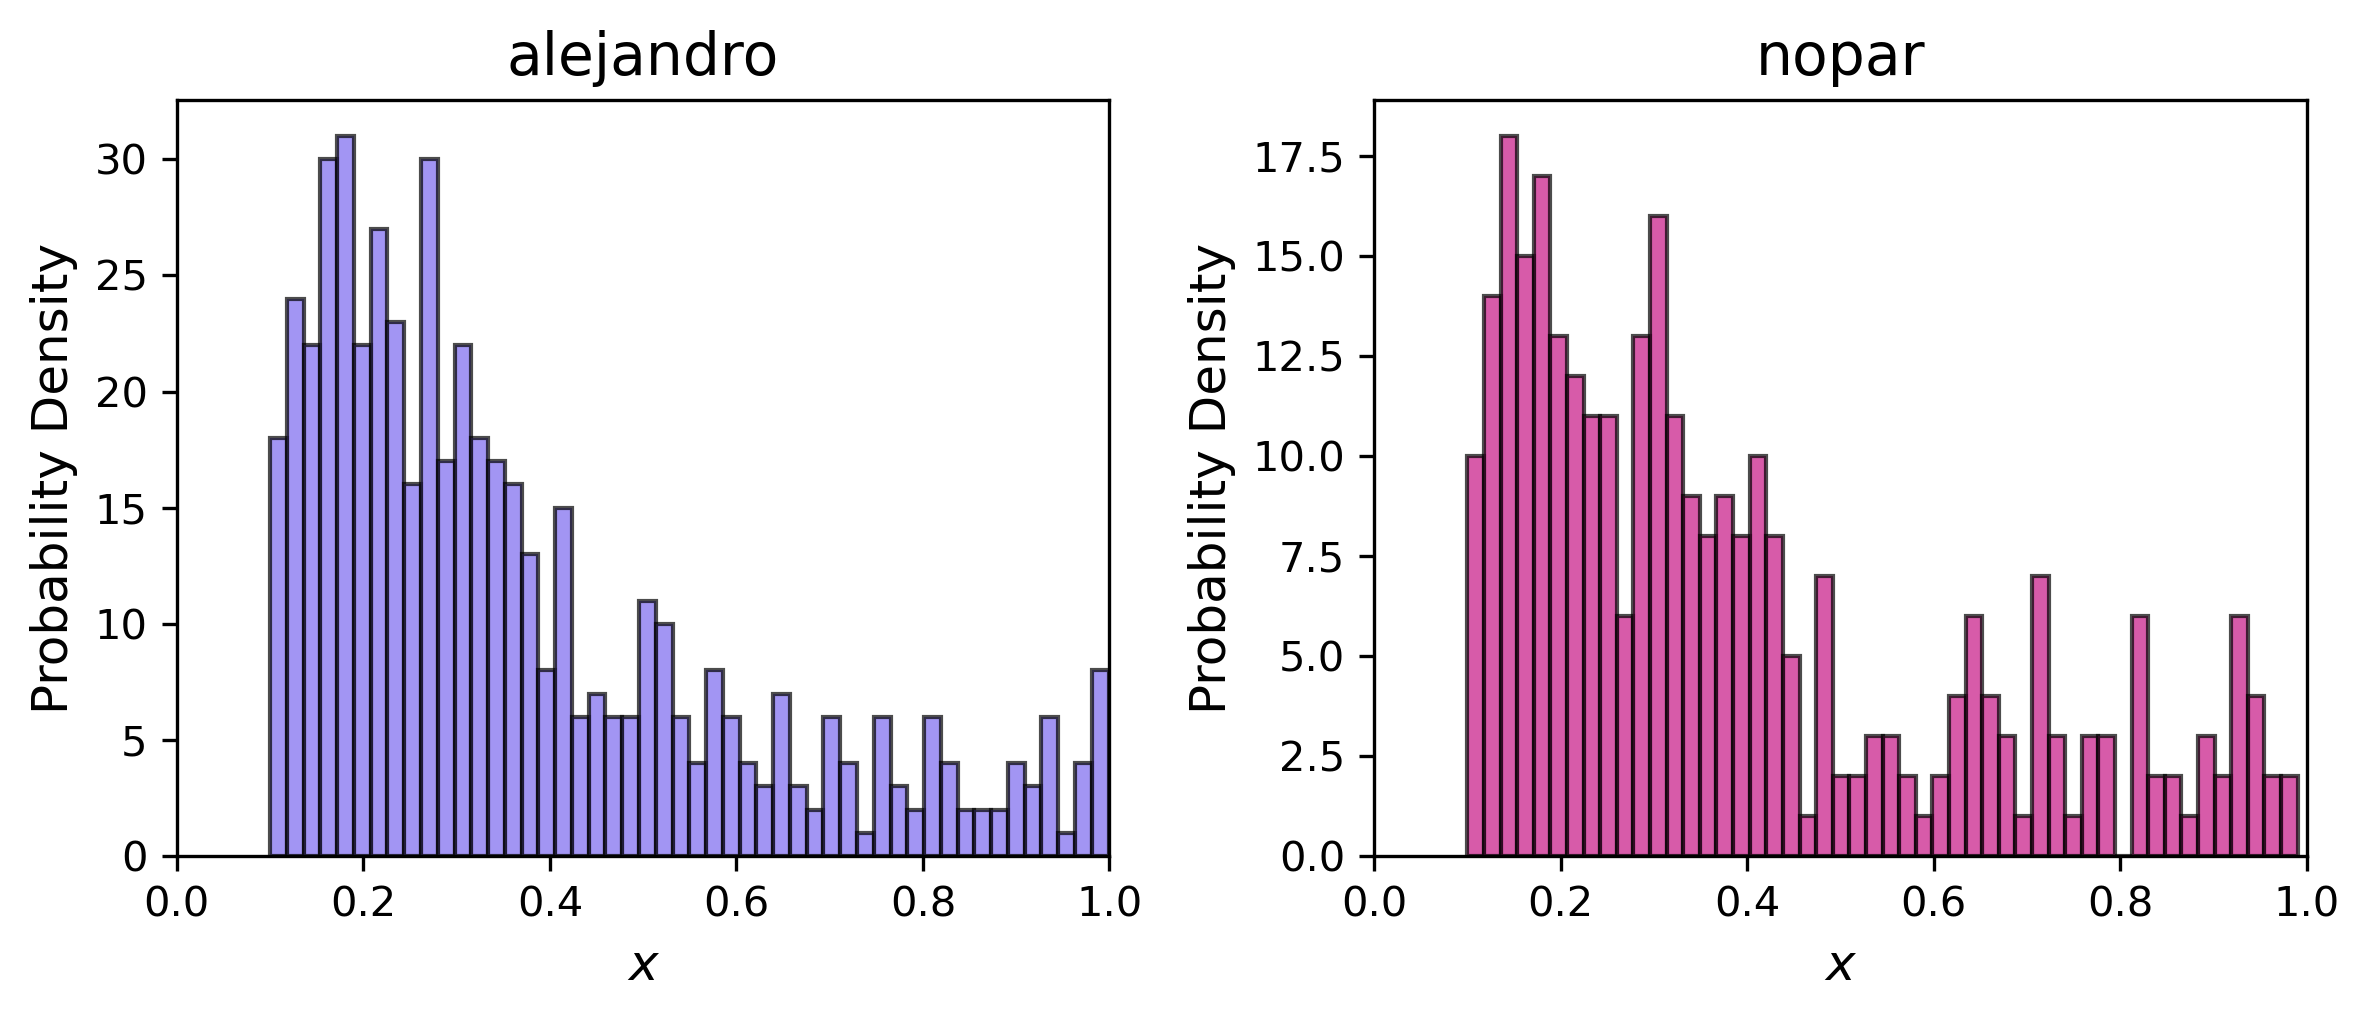

In [52]:
# PLOT TOGETHER 
# load in the data
filename_alej = f'test_vec/alej_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
with open(filename_alej, "rb") as f:
    loss_vel_alej, loss_step_alej = pickle.load(f)

filename_nopar = f'test_vec/nopar_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
with open(filename_nopar, "rb") as f:
    loss_vel_nopar, loss_step_nopar = pickle.load(f)

print(loss_vel_alej.shape)
print(loss_vel_nopar.shape)

plt.figure(figsize=(8,3.5), dpi=300)

# COMPARE THE NUMBERS OF LOST.

plt.subplot(1, 2, 1)
# plt.hist(loss_vel_alej[:,0], range=(0.1, 1), bins=50, density=True, alpha=0.7, color='mediumslateblue', edgecolor='black')
plt.hist(loss_vel_alej[:,0], range=(0.1, 0.999), bins=50, alpha=0.7, color='mediumslateblue', edgecolor='black')
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(0, 1)
plt.title('alejandro', fontsize=14)

plt.subplot(1, 2, 2)
# plt.hist(loss_vel_nopar[:,0], range=(0.1, 1), bins=50, density=True, alpha=0.7, color='mediumvioletred', edgecolor='black')
plt.hist(loss_vel_nopar[:,0], range=(0.1, 0.99), bins=50, alpha=0.7, color='mediumvioletred', edgecolor='black')
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(0, 1)
plt.title('nopar', fontsize=14)

plt.tight_layout()
plt.show()

# TESTING TIME - DXX =/= 0

In [ ]:
# full 3.5 minutes 1e3 particles
filename = f'test_vec/full_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
loss_vel, loss_step, _ = mc.run_mc(ISOTROPIC_SOURCE, numsteps=NUMSTEPS, D_func=col.D_xxi, A_func=col.A_xxi, dt=DT, R=R, Phi=PHI)

with open(filename, "wb") as f:
    pickle.dump((loss_vel, loss_step), f)

 54%|█████▍    | 538976/1000000 [03:37<03:05, 2482.02it/s]


In [48]:
# no geom 1.5 minutesfor 100 particles 
filename = f'test_vec/nogeom_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
loss_vel, loss_step, _ = mc.run_mc(ISOTROPIC_SOURCE, numsteps=NUMSTEPS, D_func=col.D_xxi, A_func=col.A_nogeom, dt=DT, R=R, Phi=PHI)

with open(filename, "wb") as f:
    pickle.dump((loss_vel, loss_step), f)

 21%|██        | 205679/1000000 [01:17<04:59, 2649.08it/s]


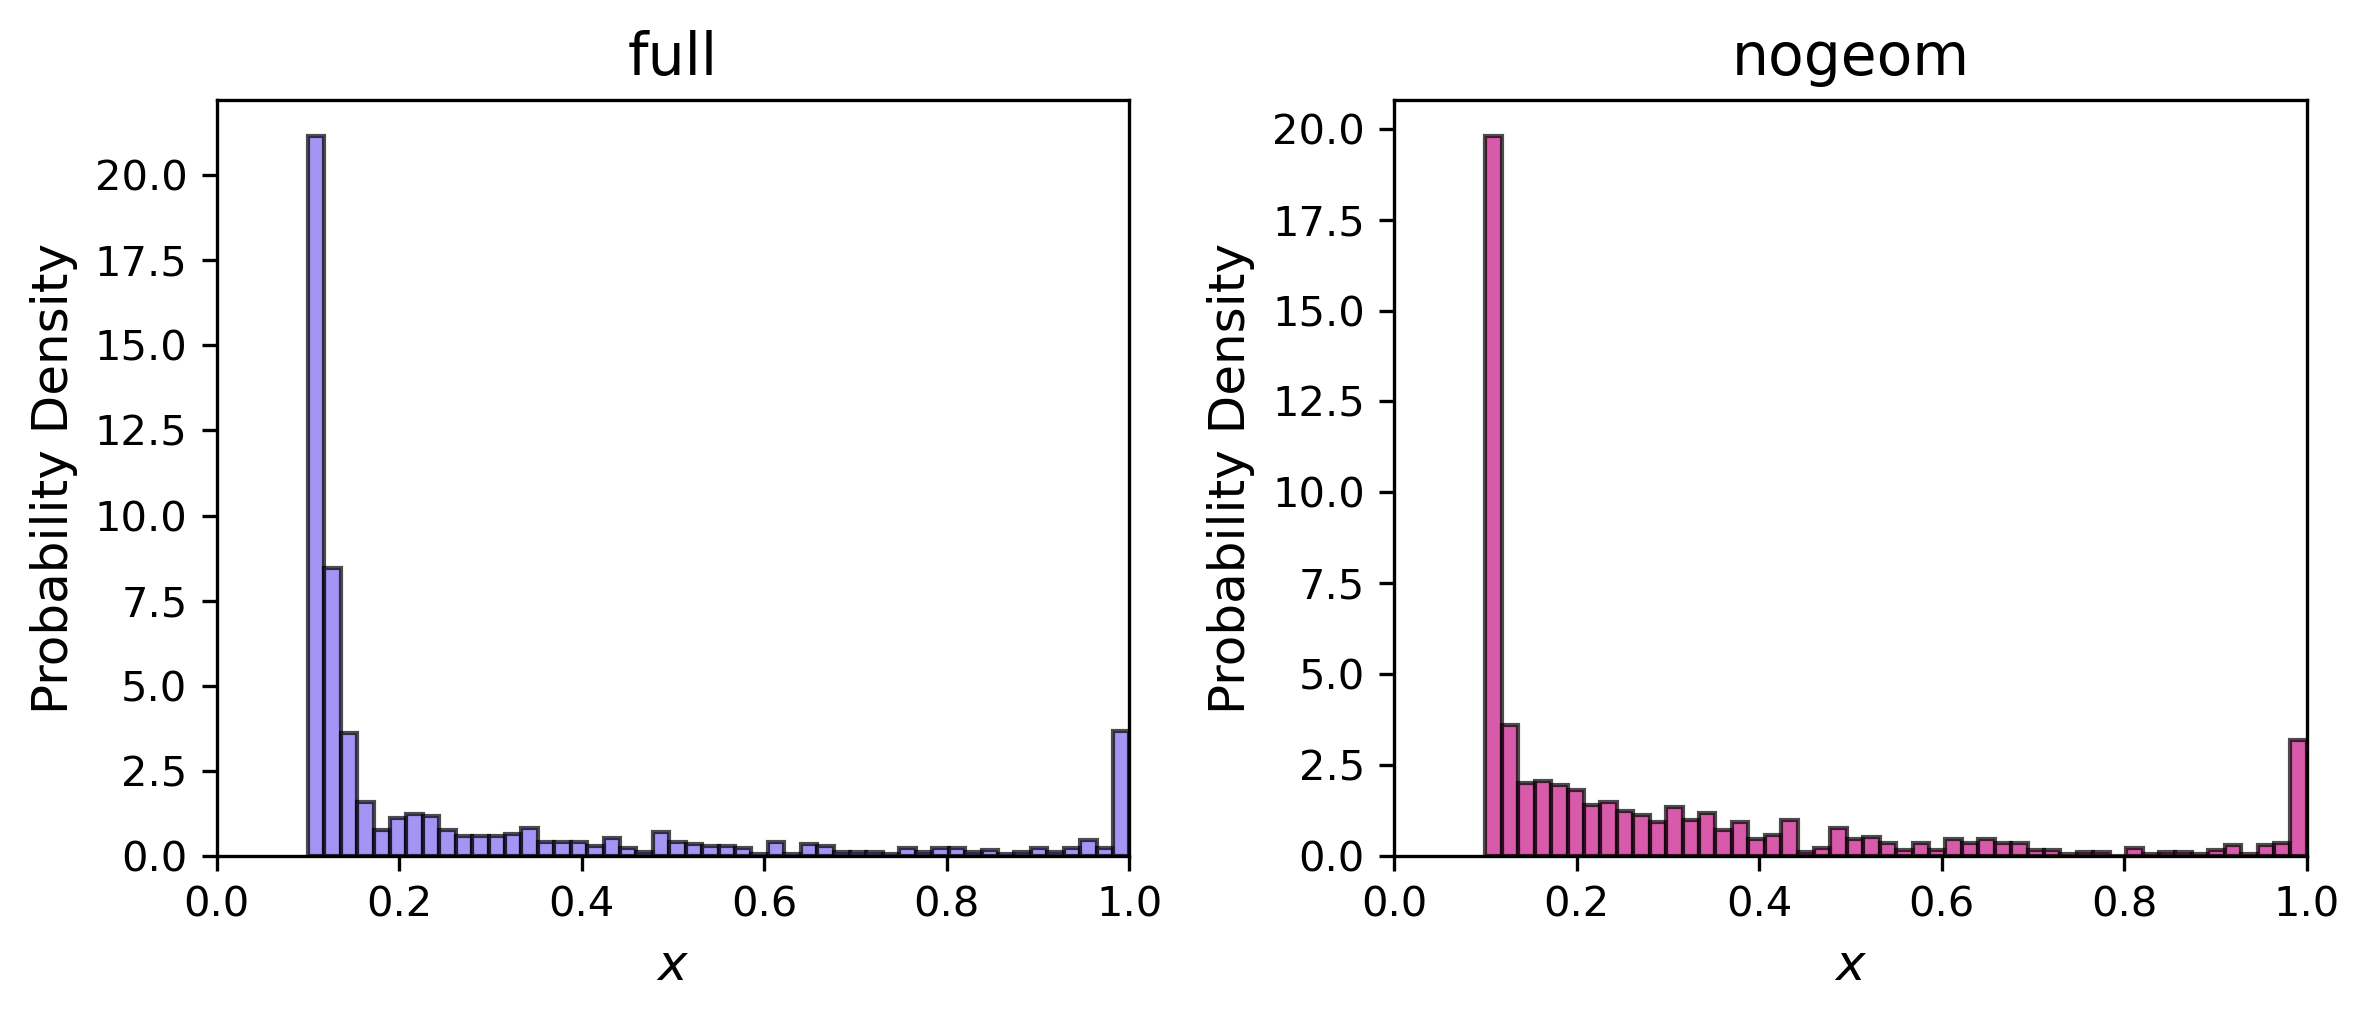

In [50]:
# PLOT TOGETHER 
# load in the data
filename_full = f'test_vec/full_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
with open(filename_full, "rb") as f:
    loss_vel_full, loss_step_full = pickle.load(f)

filename_nogeom = f'test_vec/nogeom_num{NUMPARTICLES}_dt{DT}_steps{NUMSTEPS}_R{R}_Phi{PHI}.pkl'
with open(filename_nogeom, "rb") as f:
    loss_vel_nogeom, loss_step_nogeom = pickle.load(f)

plt.figure(figsize=(8,3.5), dpi=300)

plt.subplot(1, 2, 1)
plt.hist(loss_vel_full[:,0], range=(0.1, 1), bins=50, density=True, alpha=0.7, color='mediumslateblue', edgecolor='black')
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(0, 1)
plt.title('full', fontsize=14)

plt.subplot(1, 2, 2)
plt.hist(loss_vel_nogeom[:,0], range=(0.1, 1), bins=50, density=True, alpha=0.7, color='mediumvioletred', edgecolor='black')
plt.xlabel(r'$x$', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.xlim(0, 1)
plt.title('nogeom', fontsize=14)

plt.tight_layout()
plt.show()

# PLOTTING

(8, 2)


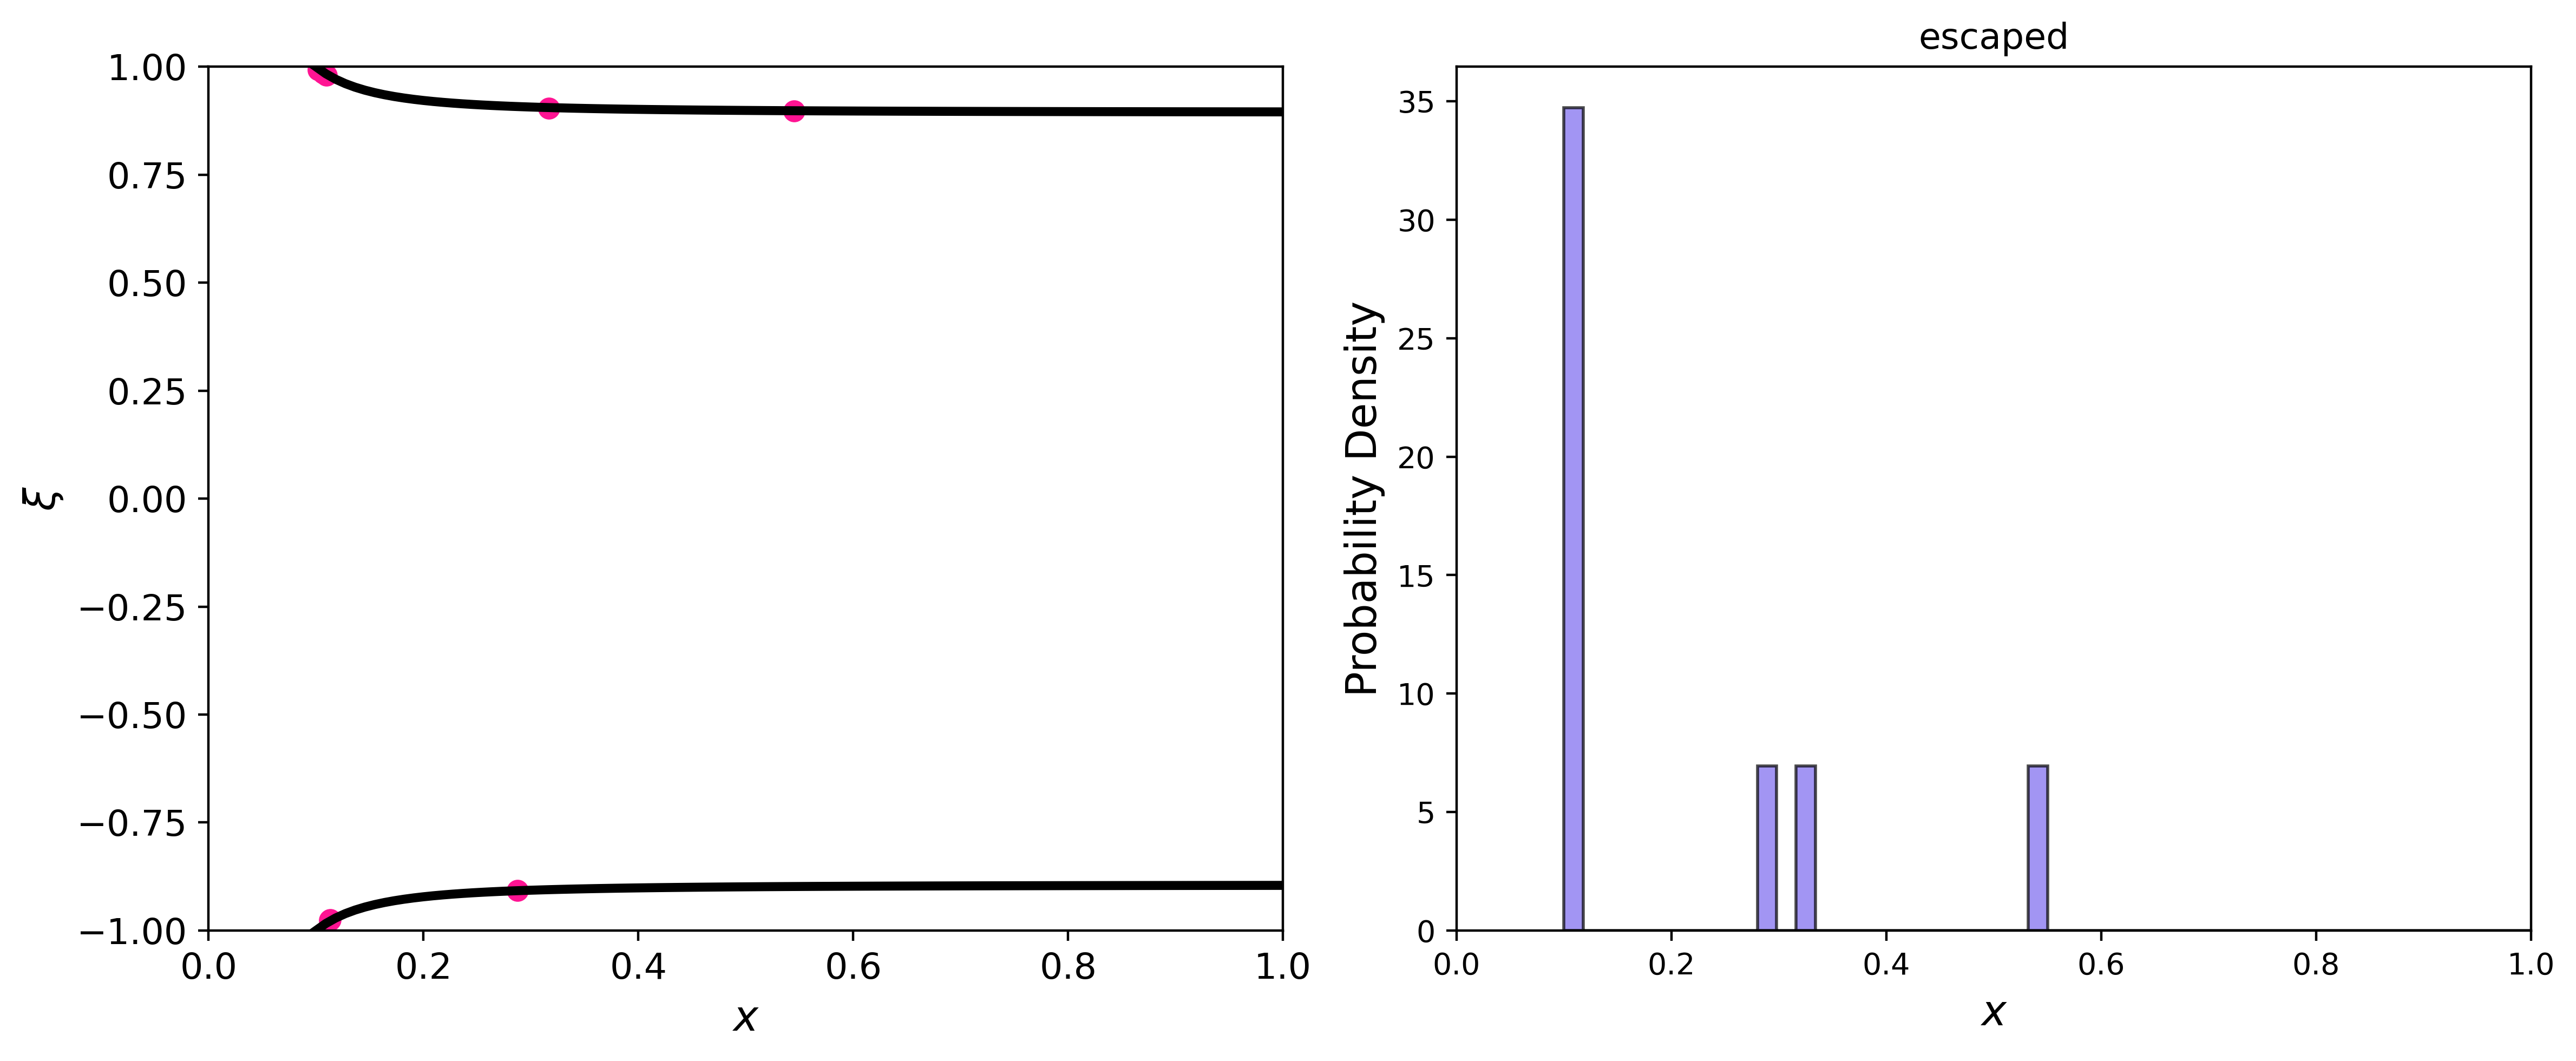

In [6]:
# plot testing script
v_store = loss_vel
print(loss_vel.shape)

x = v_store[:,0]
y = v_store[:,1]

x_values = v_store[:,0]
xmax = 1
x_line = np.linspace(1e-1, xmax, 100)

fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi=400)

axs[0].scatter(x, y, color='deeppink', s=40)
axs[0].plot(x_line, np.sqrt(1 - (1 - PHI**2/x_line**2) / R), linewidth=3, color='black')
axs[0].plot(x_line, -np.sqrt(1 - (1 - PHI**2/x_line**2) / R), linewidth=3, color='black')
axs[0].set_xlabel(r'$x$', fontsize=14)
axs[0].set_ylabel(r'$\xi$', fontsize=14)
axs[0].tick_params(axis='both', labelsize=12)
axs[0].axhline(1.01, color='black', linewidth=2, linestyle=':')
axs[0].axhline(-1.01, color='black', linewidth=2, linestyle=':')
axs[0].set_ylim(-1,1)
axs[0].set_xlim(0, xmax)

axs[1].hist(x_values, range=(0.1, 1), bins=50, density=True, alpha=0.7,
            color='mediumslateblue', edgecolor='black')
axs[1].set_xlabel(r'$x$', fontsize=14)
axs[1].set_ylabel('Probability Density', fontsize=14)
axs[1].set_xlim(0, xmax)

plt.title('escaped')
plt.tight_layout()
plt.show()
